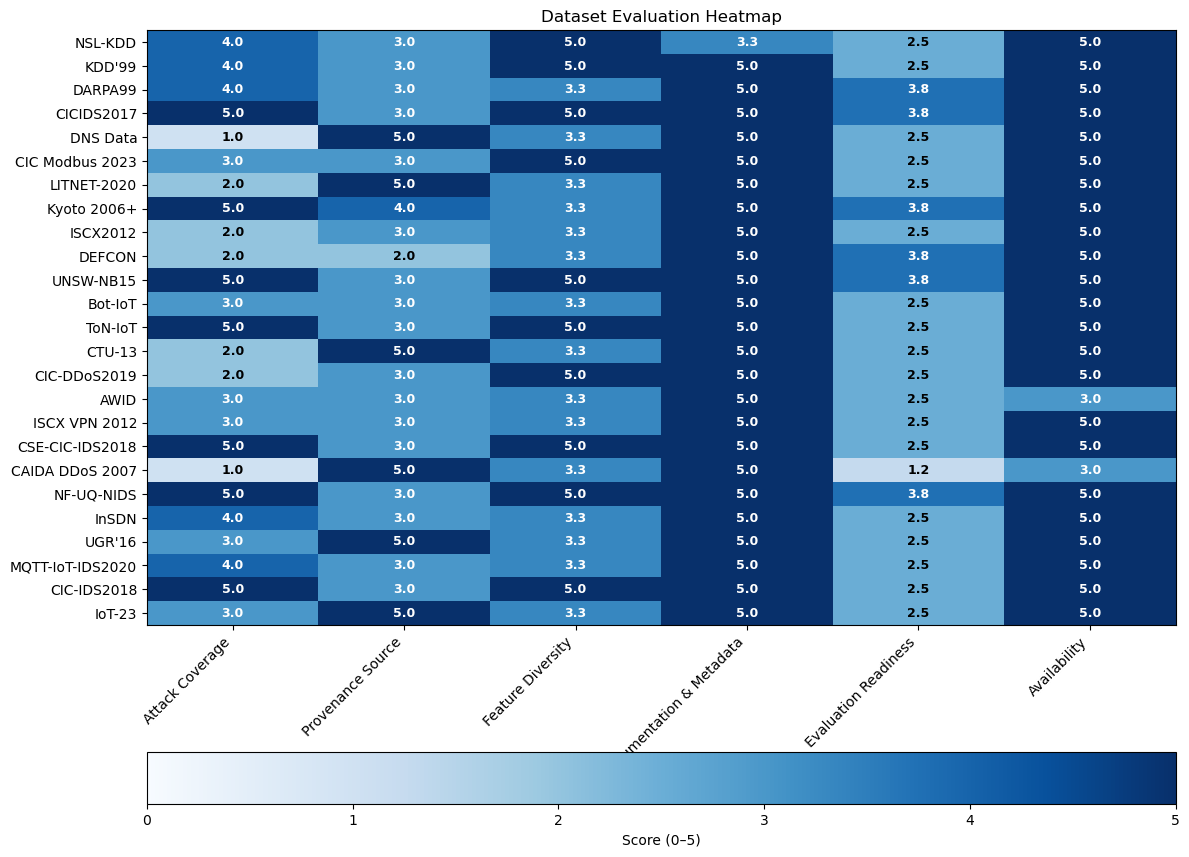

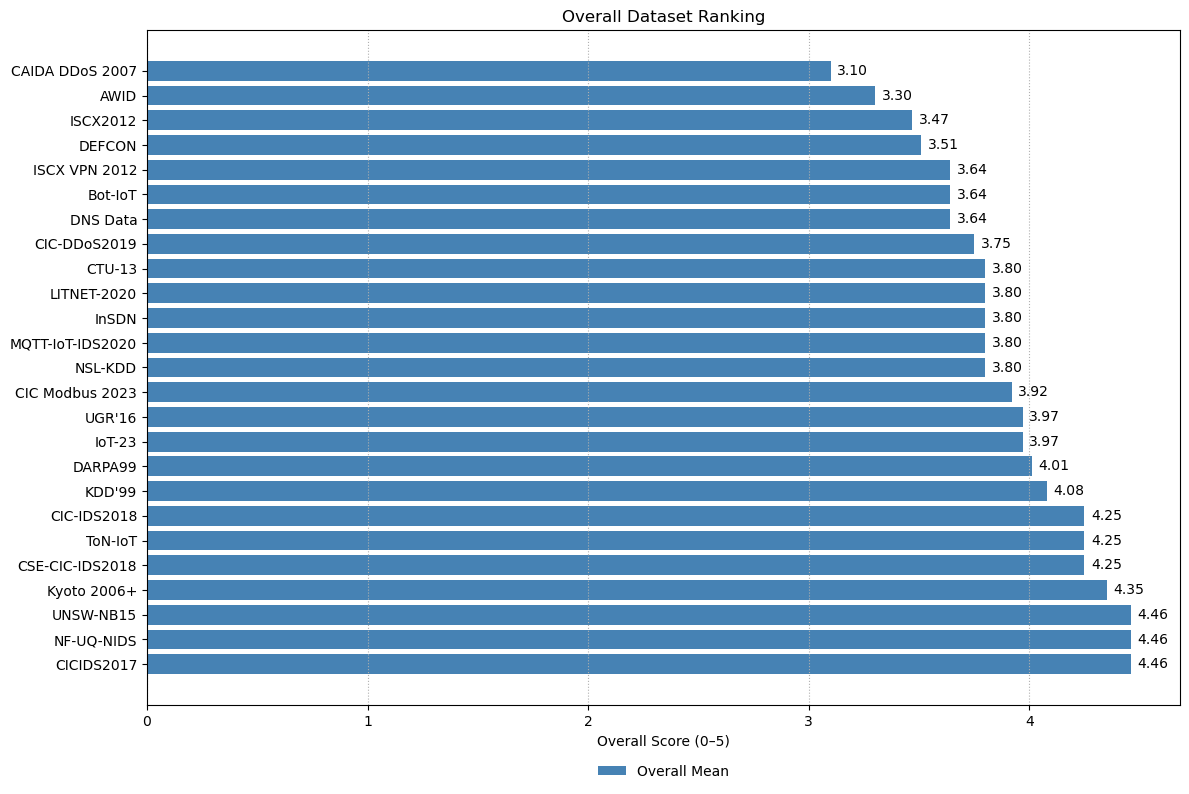

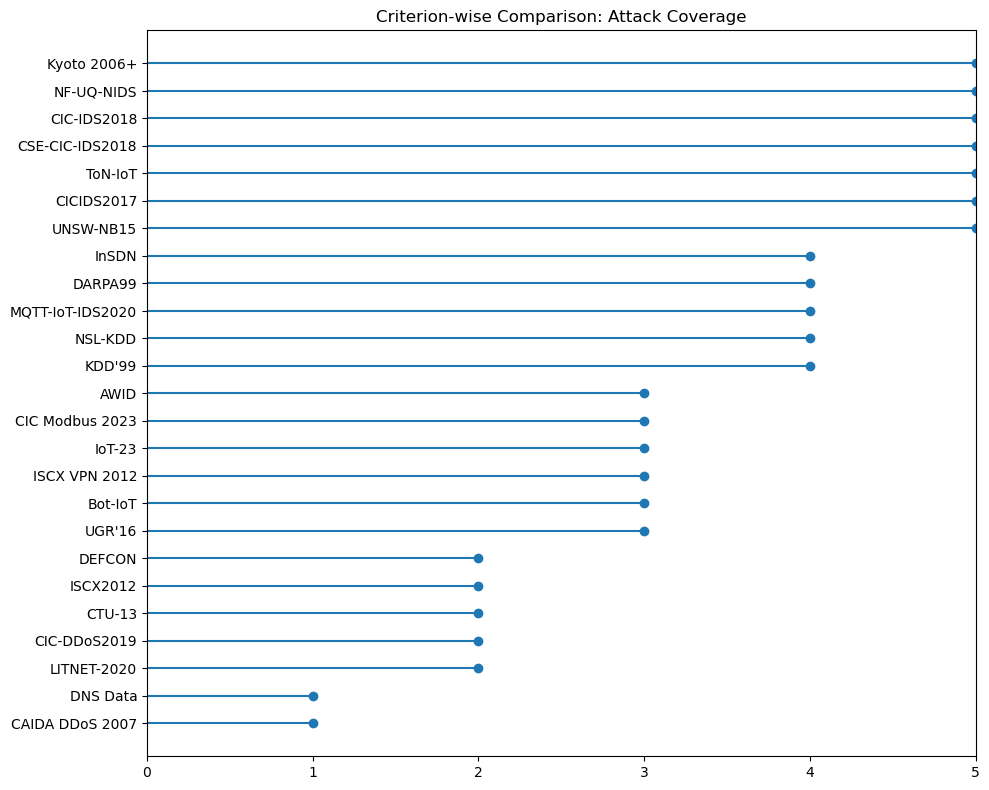

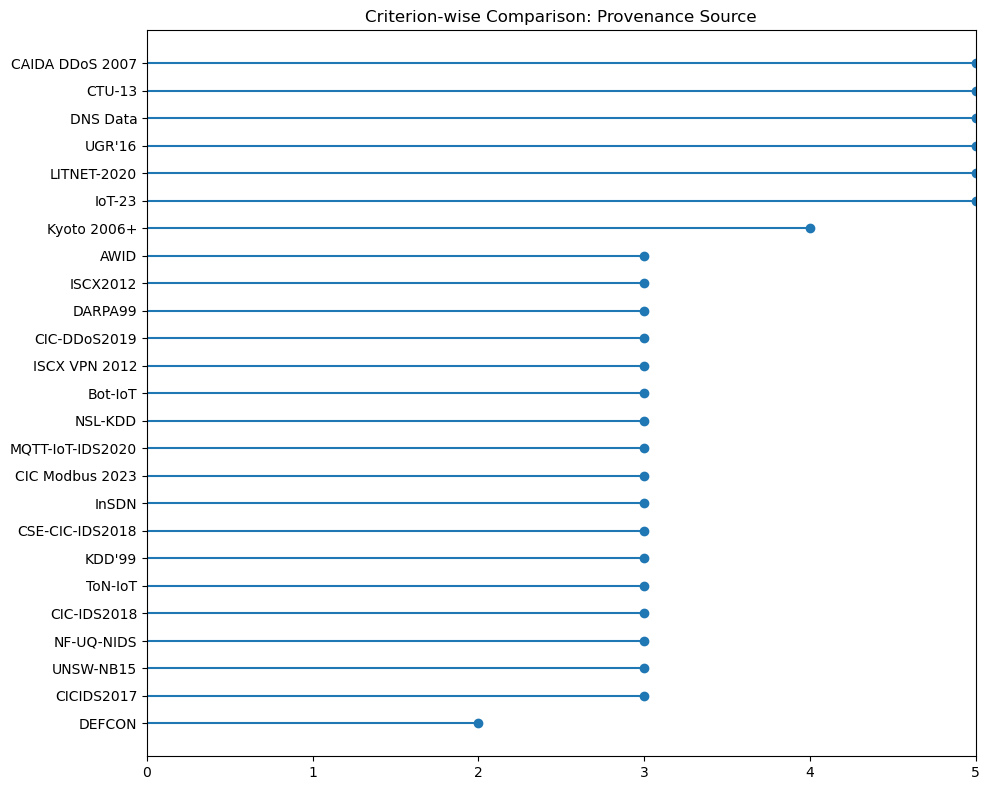

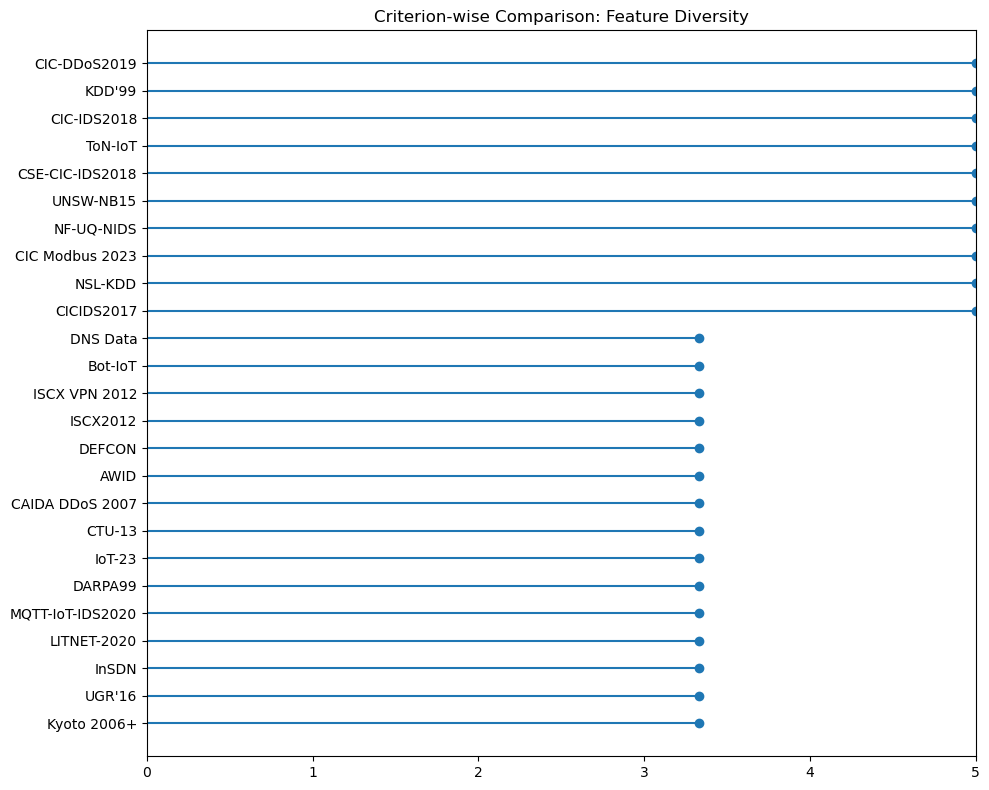

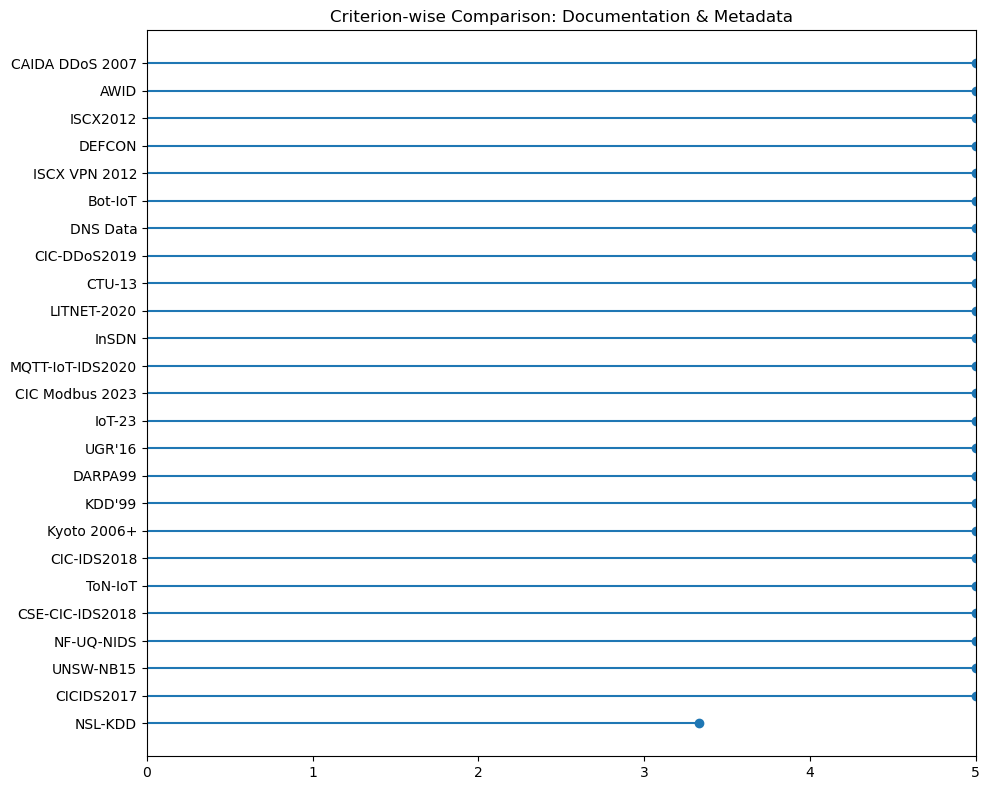

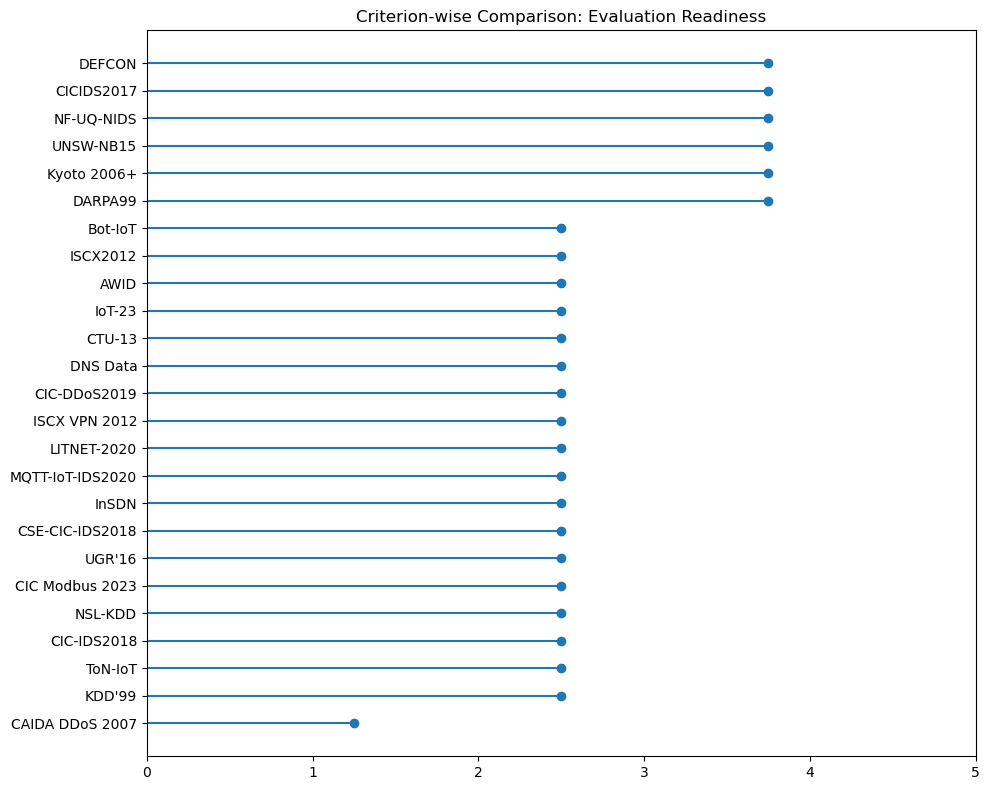

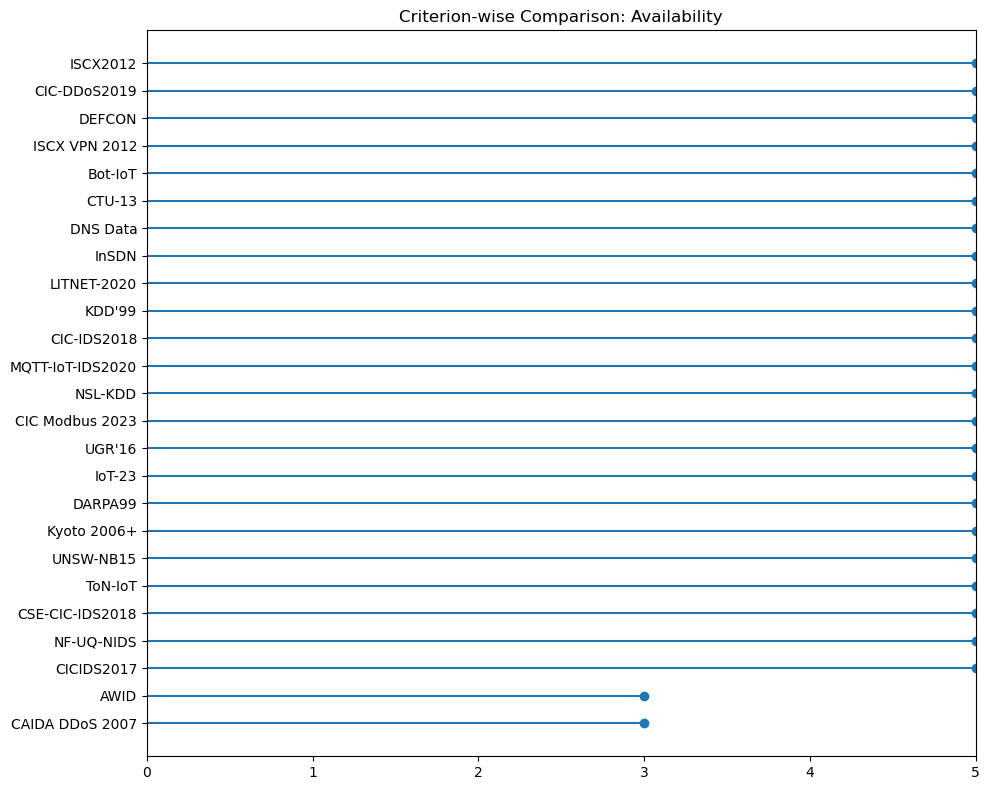

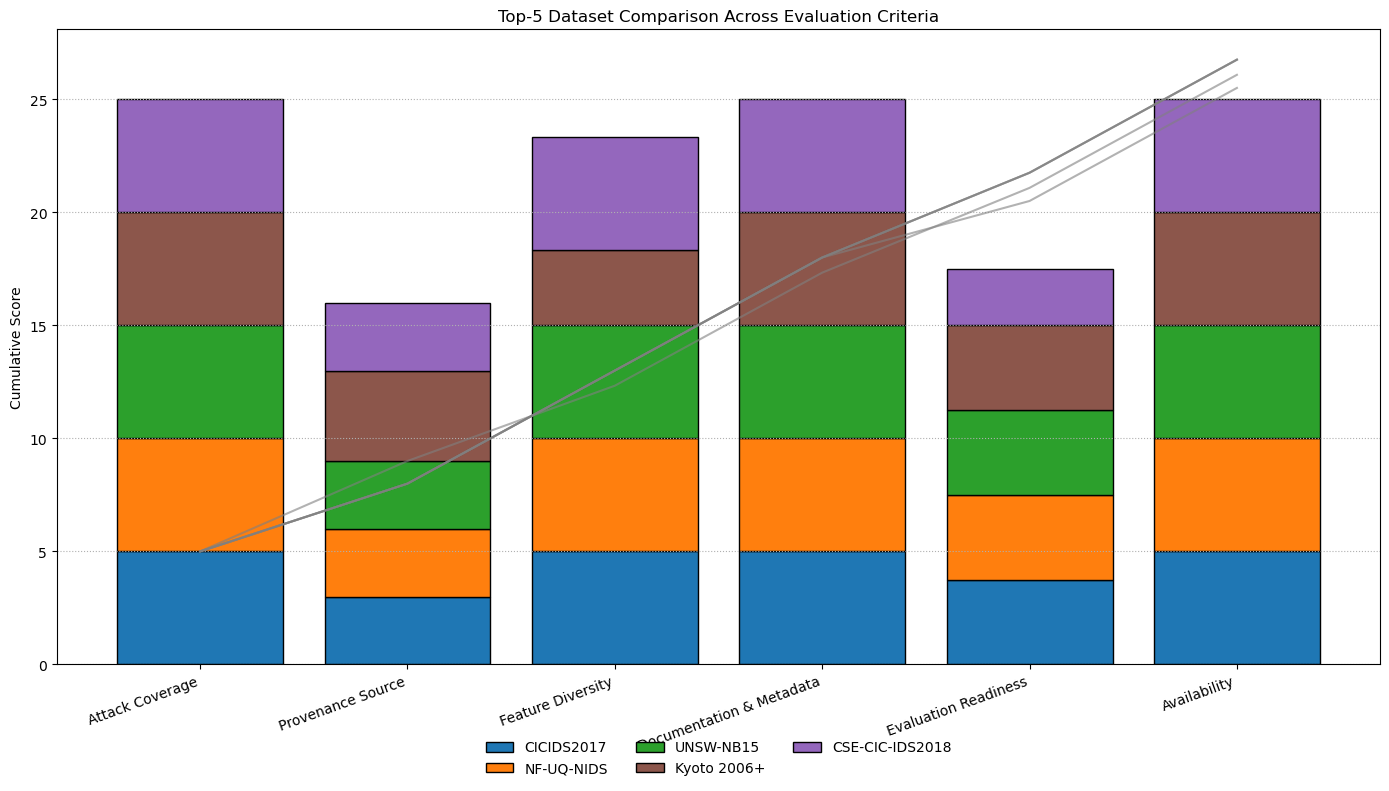

 DONE — Clean, consistent outputs generated.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
SRC_CSV    = Path("Full_Dataset_Revised_V2.csv")
OUT_SCORES = Path("dataset_scores_revised.csv")

# ============================================================
# CONFIG
# ============================================================
ATTACK_COLS  = ["C1_Recon", "C2_InitComp", "C3_PrivMis", "C4_PersistCtrl", "C5_Impact"]
FEATURE_COLS = ["Basic_Feature", "Traffic_Feature", "Content_Feature"]

META_COLS = {
    "Release_Year": "Release_Year",
    "Meta_Data": "Meta_Data",
    "Data_Format": "Data_Format"
}

EVAL_COLS = {
    "Labelled": "Labelled",
    "Predefine_Split": "Predefine_Split",
    "Benign_Data": "Benign_Data",
    "Balanced": "Balanced"
}

AVAIL_COL = "Availability"
SOURCE_CODE_TO_SCORE = {5:5, 4:4, 3:3, 2:2, 1:1}

# ============================================================
# HELPERS
# ============================================================
def as_bool(x):
    if pd.isna(x): return False
    if isinstance(x, (int, float)): return bool(int(x))
    if isinstance(x, str): return x.strip().lower() in {"true","yes","1"}
    return False

def is_present(x):
    if pd.isna(x): return False
    return str(x).strip() != ""

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(SRC_CSV)
df.columns = [c.strip() for c in df.columns]

# ============================================================
# SCORING FUNCTIONS
# ============================================================
def score_attack(r):
    return sum(as_bool(r[c]) for c in ATTACK_COLS)

def score_provenance(r):
    return SOURCE_CODE_TO_SCORE.get(int(r.get("Source",0)), 0)

def score_features(r):
    return round(5 * sum(as_bool(r[c]) for c in FEATURE_COLS) / 3, 2)

def score_docs(r):
    return round(
        5 * (
            is_present(r[META_COLS["Release_Year"]]) +
            as_bool(r[META_COLS["Meta_Data"]]) +
            is_present(r[META_COLS["Data_Format"]])
        ) / 3, 2
    )

def score_eval(r):
    return round(
        5 * (
            as_bool(r[EVAL_COLS["Labelled"]]) +
            as_bool(r[EVAL_COLS["Predefine_Split"]]) +
            as_bool(r[EVAL_COLS["Benign_Data"]]) +
            as_bool(r[EVAL_COLS["Balanced"]])
        ) / 4, 2
    )

def score_avail(r):
    a = str(r[AVAIL_COL]).lower()
    return 5 if "public" in a else 3 if "request" in a else 1

# ============================================================
# COMPUTE SCORES
# ============================================================
rows = []
for _, r in df.iterrows():
    vals = [
        score_attack(r),
        score_provenance(r),
        score_features(r),
        score_docs(r),
        score_eval(r),
        score_avail(r)
    ]
    rows.append({
        "Dataset": r["Dataset"],
        "Attack Coverage": vals[0],
        "Provenance Source": vals[1],
        "Feature Diversity": vals[2],
        "Documentation & Metadata": vals[3],
        "Evaluation Readiness": vals[4],
        "Availability": vals[5],
        "Overall (Mean)": round(np.mean(vals), 2)
    })

scores = pd.DataFrame(rows).set_index("Dataset")
scores.to_csv(OUT_SCORES)

scores_sorted = scores.sort_values("Overall (Mean)", ascending=False)
cat_cols = [c for c in scores.columns if c != "Overall (Mean)"]

# ============================================================
# TABLES
# ============================================================
top5 = scores_sorted.head(5)
top5[cat_cols].to_csv("Table_Top5_Evaluation.csv")
scores_sorted[["Overall (Mean)"]].to_csv("Table_Overall_Ranking.csv")

# ============================================================
# HEATMAP (ALL DATASETS – CLEAN)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 9))

M = scores[cat_cols].values
im = ax.imshow(M, cmap="Blues", vmin=0, vmax=5, aspect="auto")

ax.set_xticks(range(len(cat_cols)))
ax.set_xticklabels(cat_cols, rotation=45, ha="right")
ax.set_yticks(range(len(scores.index)))
ax.set_yticklabels(scores.index)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.1f}",
                ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white" if M[i,j] > 2.5 else "black")

cbar = fig.colorbar(im, orientation="horizontal", pad=0.15)
cbar.set_label("Score (0–5)")
cbar.set_ticks([0,1,2,3,4,5])

plt.title("Dataset Evaluation Heatmap")
plt.tight_layout()
plt.savefig("FigA1_Heatmap.png", dpi=600)
plt.show()

# ============================================================
# BAR CHART – OVERALL RANKING (ALL)
# ============================================================
fig, ax = plt.subplots(figsize=(12,8))

ax.barh(scores_sorted.index, scores_sorted["Overall (Mean)"], color="steelblue", label="Overall Mean")

for i, v in enumerate(scores_sorted["Overall (Mean)"]):
    ax.text(v + 0.03, i, f"{v:.2f}", va="center")

ax.set_xlabel("Overall Score (0–5)")
ax.set_title("Overall Dataset Ranking")
ax.grid(axis="x", linestyle=":")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), frameon=False)

plt.tight_layout()
plt.savefig("FigA4_Overall_Ranking.png", dpi=600)
plt.show()

# ============================================================
# DOT PLOTS – FIG. 5 (a–f)
# ============================================================
for cat in cat_cols:
    fig, ax = plt.subplots(figsize=(10,8))
    s = scores_sorted[[cat]].sort_values(cat)
    y = np.arange(len(s))

    ax.hlines(y, 0, s[cat])
    ax.plot(s[cat], y, "o")

    ax.set_yticks(y)
    ax.set_yticklabels(s.index)
    ax.set_xlim(0, 5)

    plt.title(f"Criterion-wise Comparison: {cat}")
    plt.tight_layout()
    plt.savefig(f"Fig5_{cat}.png", dpi=600)
    plt.show()

# ============================================================
# TOP‑5 STACKED COLUMN + SLOPE LINES
# ============================================================
fig, ax = plt.subplots(figsize=(14,8))

x = np.arange(len(cat_cols))
bottom = np.zeros(len(cat_cols))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#8c564b", "#9467bd"]

for i, ds in enumerate(top5.index):
    vals = top5.loc[ds, cat_cols].values
    ax.bar(x, vals, bottom=bottom, label=ds, color=colors[i], edgecolor="black")
    bottom += vals

for i, ds in enumerate(top5.index):
    ax.plot(x, top5.loc[ds, cat_cols].cumsum(), color="gray", alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(cat_cols, rotation=20, ha="right")
ax.set_ylabel("Cumulative Score")
ax.set_title("Top‑5 Dataset Comparison Across Evaluation Criteria")
ax.grid(axis="y", linestyle=":")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("Fig_Top5_Stacked_Slope.png", dpi=600)
plt.show()

print(" DONE — Clean, consistent outputs generated.")

In [2]:
# ============================================================
# === SENSITIVITY ANALYSIS (Ranking Robustness Test)
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------
# Load computed scores
# ------------------------------
scores_sa = pd.read_csv("dataset_scores_revised.csv").set_index("Dataset")

# Categories EXACTLY as used in your pipeline
CATS = [
    "Attack Coverage",
    "Provenance Source",
    "Feature Diversity",
    "Documentation & Metadata",
    "Evaluation Readiness",
    "Availability",
]

# ------------------------------
# Helpers
# ------------------------------
def weighted_composite(df: pd.DataFrame, weights: dict) -> pd.Series:
    w = np.array([weights[c] for c in CATS], dtype=float)
    w = w / w.sum()
    return pd.Series((df[CATS].values * w).sum(axis=1), index=df.index)

def spearman_rho(rank_a: pd.Series, rank_b: pd.Series) -> float:
    a = rank_a.to_numpy(dtype=float)
    b = rank_b.to_numpy(dtype=float)
    a_mean = a.mean()
    b_mean = b.mean()
    num = ((a - a_mean) * (b - b_mean)).sum()
    den = np.sqrt(((a - a_mean) ** 2).sum() * ((b - b_mean) ** 2).sum())
    return float(num / den) if den != 0 else float("nan")

# ------------------------------
# Weight schemes
# ------------------------------
W_EQUAL = {c: 1 / len(CATS) for c in CATS}

# Provenance emphasis (30%)
W_PROV = {c: (1 - 0.30) / (len(CATS) - 1) for c in CATS}
W_PROV["Provenance Source"] = 0.30

# Evaluation readiness emphasis (30%)
W_EVAL = {c: (1 - 0.30) / (len(CATS) - 1) for c in CATS}
W_EVAL["Evaluation Readiness"] = 0.30

# ------------------------------
# Compute composite scores
# ------------------------------
comp_equal = weighted_composite(scores_sa, W_EQUAL).rename("Equal")
comp_prov  = weighted_composite(scores_sa, W_PROV).rename("ProvenanceEmphasis")
comp_eval  = weighted_composite(scores_sa, W_EVAL).rename("EvalReadinessEmphasis")

composites = pd.concat([comp_equal, comp_prov, comp_eval], axis=1)

# ------------------------------
# Rank datasets (1 = best)
# ------------------------------
ranks = composites.rank(ascending=False, method="min").astype(int)

# ------------------------------
# Rank stability (Spearman rho)
# ------------------------------
rho_eq_prov = spearman_rho(ranks["Equal"], ranks["ProvenanceEmphasis"])
rho_eq_eval = spearman_rho(ranks["Equal"], ranks["EvalReadinessEmphasis"])

print("\n=== Sensitivity Analysis Summary ===")
print("Number of datasets:", len(ranks))
print("Spearman ρ (Equal vs Provenance emphasis):", round(rho_eq_prov, 4))
print("Spearman ρ (Equal vs Eval‑Readiness emphasis):", round(rho_eq_eval, 4))

# ------------------------------
# Save appendix‑ready tables
# ------------------------------
weights_table = pd.DataFrame(
    [
        ["Equal", *[W_EQUAL[c] for c in CATS]],
        ["Provenance‑emphasis", *[W_PROV[c] for c in CATS]],
        ["Evaluation‑readiness emphasis", *[W_EVAL[c] for c in CATS]],
    ],
    columns=["Scheme", *CATS]
)

weights_table.to_csv("Appendix_Weight_Vectors.csv", index=False)
ranks.to_csv("Appendix_Ranks_By_Weighting.csv")
composites.to_csv("Appendix_Composite_Scores_By_Weighting.csv")

print("\nSaved appendix tables:")
print("- Appendix_Weight_Vectors.csv")
print("- Appendix_Ranks_By_Weighting.csv")
print("- Appendix_Composite_Scores_By_Weighting.csv")



=== Sensitivity Analysis Summary ===
Number of datasets: 25
Spearman ρ (Equal vs Provenance emphasis): 0.9272
Spearman ρ (Equal vs Eval‑Readiness emphasis): 0.9811

Saved appendix tables:
- Appendix_Weight_Vectors.csv
- Appendix_Ranks_By_Weighting.csv
- Appendix_Composite_Scores_By_Weighting.csv
